# SafeTraj-Experiments — Demo Notebook

**Analysis of Neural Trajectory Prediction for Collision Avoidance in Smart Wheelchairs**

This notebook reproduces the key findings from the MSc thesis research using **synthetic data**.
No proprietary datasets or model weights are used — all data is generated to match the
statistical properties and operational ranges defined in the REXASI-PRO project.

---

**Author:** Pouya Bathaei Pourmand  
**Affiliation:** MSc in Computer Engineering (AI) — University of Genoa / CNR  
**Project:** REXASI-PRO — EU Horizon Europe  

---

## What this notebook covers

1. **Experiment 1 — Input Sensitivity:** How orientation (φ), linear velocity (v), and angular velocity (ω) affect trajectory stability
2. **Experiment 2 — Goal Difficulty:** Which target positions are harder for neural predictors
3. **Key Finding:** Orientation φ is the dominant risk factor
4. **Model Comparison:** Success rates across 5 DNN-LNA architectures

In [1]:
# Install dependencies if needed
# !pip install numpy matplotlib pandas scikit-learn seaborn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Synthetic Data Generation

We generate synthetic trajectory data matching the operational ranges of the REXASI-PRO wheelchair platform:
- Orientation φ ∈ [−π, π]
- Linear velocity v ∈ [−1.05, 2.88] m/s
- Angular velocity ω ∈ [−1.99, 1.99] rad/s

In [3]:
def generate_synthetic_data(n_samples=500, seed=42):
    """
    Generate synthetic trajectory evaluation data.

    Simulates the key pattern found in the thesis:
    - Orientation near ±π → high failure rate
    - Central orientations → high success rate
    """
    np.random.seed(seed)

    # Sample input commands
    phi = np.random.uniform(-np.pi, np.pi, n_samples)      # orientation
    v_lin = np.random.uniform(-1.05, 2.88, n_samples)       # linear velocity
    v_rot = np.random.uniform(-1.99, 1.99, n_samples)       # angular velocity

    # Simulate failure probability based on thesis findings
    # Key finding: orientation is dominant risk factor
    orientation_risk = np.abs(np.cos(phi / 2))  # high risk near ±π
    velocity_risk = np.abs(v_rot) / 1.99 * 0.2  # secondary factor

    failure_prob = (1 - orientation_risk) * 0.8 + velocity_risk
    failure_prob = np.clip(failure_prob, 0, 1)

    # Simulate final distance to goal
    base_distance = np.random.exponential(0.15, n_samples)
    distance = base_distance + failure_prob * np.random.uniform(0, 1.5, n_samples)

    # Success criteria
    strict_success = distance < 0.30
    near_success = (distance >= 0.30) & (distance < 0.50)
    failure = distance >= 0.50

    return pd.DataFrame({
        'phi': phi,
        'v_lin': v_lin,
        'v_rot': v_rot,
        'distance': distance,
        'strict_success': strict_success,
        'near_success': near_success,
        'failure': failure,
        'label': np.where(strict_success, 'success',
                 np.where(near_success, 'near-success', 'failure'))
    })

df = generate_synthetic_data(n_samples=500)
print(f'Generated {len(df)} samples')
print(f'Success rate: {df["strict_success"].mean():.1%}')
print(f'Near-success rate: {df["near_success"].mean():.1%}')
print(f'Failure rate: {df["failure"].mean():.1%}')
df.head()

Generated 500 samples
Success rate: 41.2%
Near-success rate: 21.4%
Failure rate: 37.4%


,phi,v_lin,v_rot,distance,strict_success,near_success,failure,label
0,-0.788288,1.693776,-1.253171,0.183330,True,False,False,success
1,2.831922,1.056859,0.166766,0.354731,False,True,False,near-success
2,1.457661,0.166444,1.484324,0.482963,False,True,False,near-success
3,0.619890,2.148214,0.924255,0.111651,True,False,False,success
4,-2.161299,1.640994,1.220113,0.294488,True,False,False,success


---
## 2. Experiment 1 — Input Sensitivity Analysis

### Key Finding: Orientation φ is the dominant risk factor

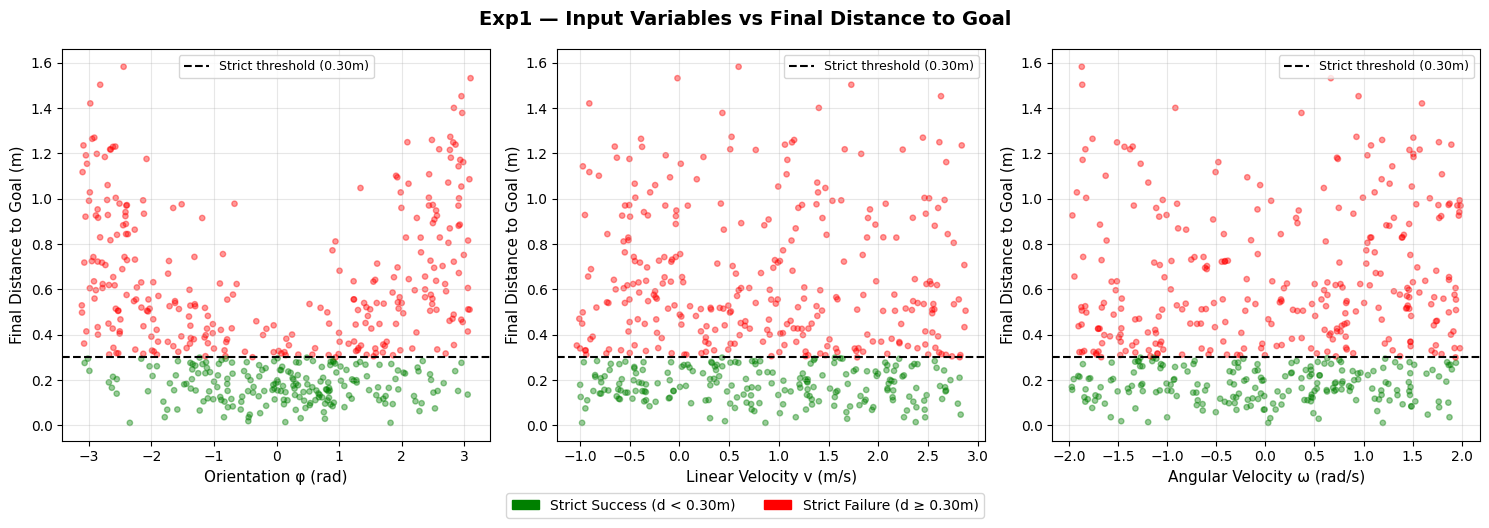

Key observation: Failures concentrate near φ = ±π (robot facing away from goal)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Exp1 — Input Variables vs Final Distance to Goal', fontsize=14, fontweight='bold')

variables = [
    ('phi', 'Orientation φ (rad)', axes[0]),
    ('v_lin', 'Linear Velocity v (m/s)', axes[1]),
    ('v_rot', 'Angular Velocity ω (rad/s)', axes[2]),
]

colors = df['strict_success'].map({True: 'green', False: 'red'})

for col, label, ax in variables:
    ax.scatter(df[col], df['distance'], c=colors, alpha=0.4, s=15)
    ax.axhline(y=0.30, color='black', linestyle='--', linewidth=1.5, label='Strict threshold (0.30m)')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Final Distance to Goal (m)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Add legend
success_patch = mpatches.Patch(color='green', label='Strict Success (d < 0.30m)')
failure_patch = mpatches.Patch(color='red', label='Strict Failure (d ≥ 0.30m)')
fig.legend(handles=[success_patch, failure_patch], loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('exp1_input_sensitivity_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key observation: Failures concentrate near φ = ±π (robot facing away from goal)')

### Risk Map — Orientation vs Angular Velocity

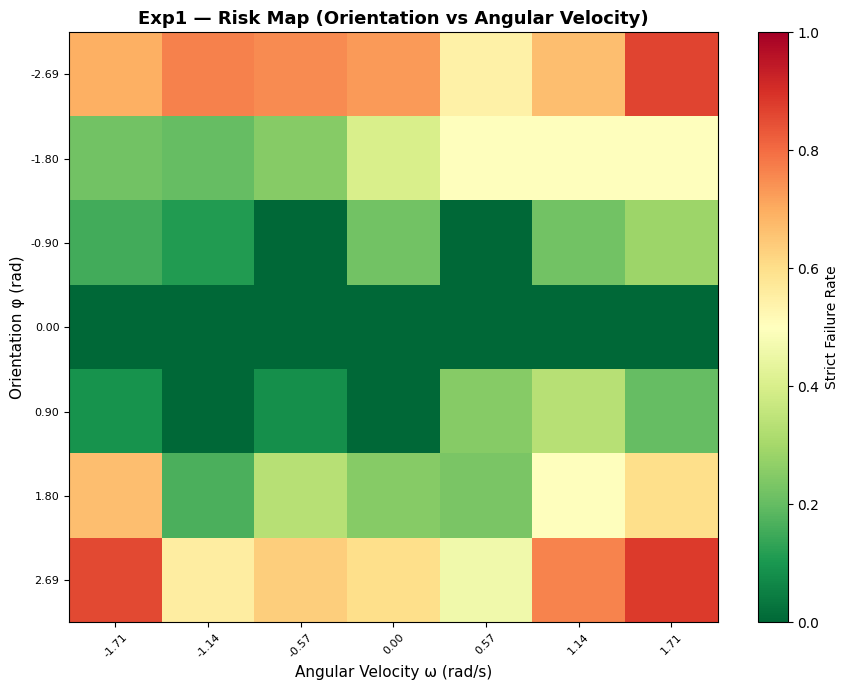

Red = high failure rate | Green = low failure rate


In [5]:
# Bin the data and compute failure rates
phi_bins = np.linspace(-np.pi, np.pi, 8)
omega_bins = np.linspace(-1.99, 1.99, 8)

df['phi_bin'] = pd.cut(df['phi'], bins=phi_bins)
df['omega_bin'] = pd.cut(df['v_rot'], bins=omega_bins)

risk_map = df.groupby(['phi_bin', 'omega_bin'], observed=True)['failure'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(risk_map.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Strict Failure Rate')

ax.set_title('Exp1 — Risk Map (Orientation vs Angular Velocity)', fontsize=13, fontweight='bold')
ax.set_xlabel('Angular Velocity ω (rad/s)', fontsize=11)
ax.set_ylabel('Orientation φ (rad)', fontsize=11)

n_phi = len(risk_map.index)
n_omega = len(risk_map.columns)
ax.set_yticks(range(n_phi))
ax.set_yticklabels([f'{x.mid:.2f}' for x in risk_map.index], fontsize=8)
ax.set_xticks(range(n_omega))
ax.set_xticklabels([f'{x.mid:.2f}' for x in risk_map.columns], fontsize=8, rotation=45)

plt.tight_layout()
plt.savefig('exp1_risk_map_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red = high failure rate | Green = low failure rate')

---
## 3. Experiment 2 — Goal Difficulty Analysis

### Soft Success Distribution across Models

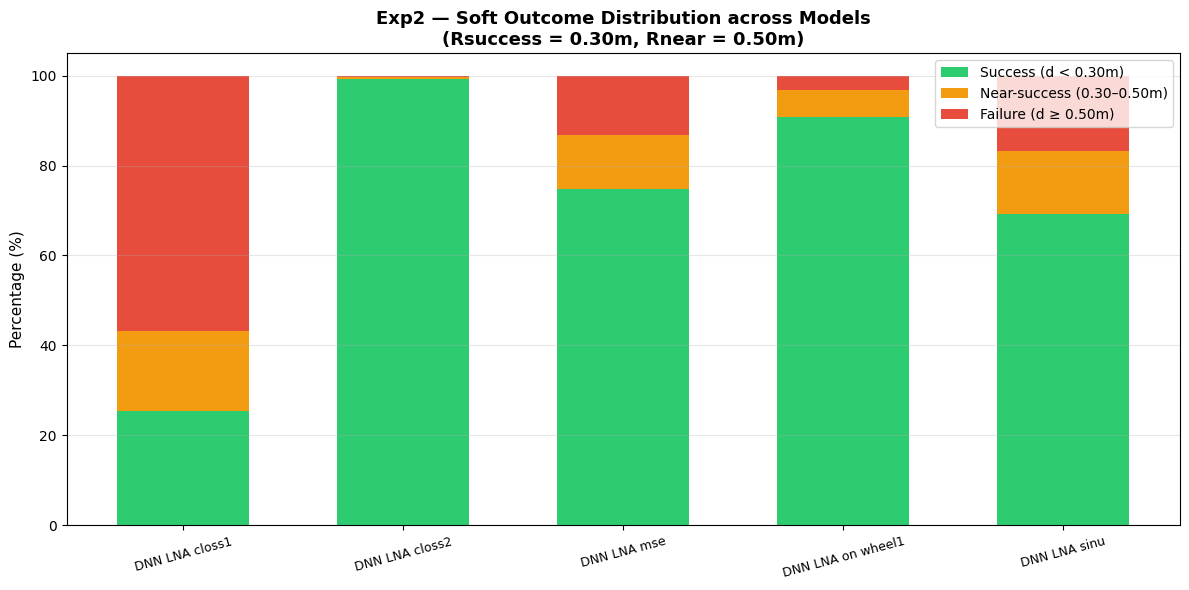

In [6]:
# Simulate results for 5 DNN-LNA models (matching thesis findings)
models = {
    'DNN_LNA_closs1': {'success': 25.3, 'near': 18.0, 'failure': 56.7},
    'DNN_LNA_closs2': {'success': 99.3, 'near': 0.5,  'failure': 0.2},
    'DNN_LNA_mse':    {'success': 74.7, 'near': 12.0, 'failure': 13.3},
    'DNN_LNA_on_wheel1': {'success': 90.7, 'near': 6.0, 'failure': 3.3},
    'DNN_LNA_sinu':   {'success': 69.2, 'near': 14.0, 'failure': 16.8},
}

model_names = list(models.keys())
success_vals = [models[m]['success'] for m in model_names]
near_vals = [models[m]['near'] for m in model_names]
failure_vals = [models[m]['failure'] for m in model_names]

x = np.arange(len(model_names))
width = 0.6

fig, ax = plt.subplots(figsize=(12, 6))
p1 = ax.bar(x, success_vals, width, label='Success (d < 0.30m)', color='#2ecc71')
p2 = ax.bar(x, near_vals, width, bottom=success_vals, label='Near-success (0.30–0.50m)', color='#f39c12')
p3 = ax.bar(x, failure_vals, width,
            bottom=[s+n for s,n in zip(success_vals, near_vals)],
            label='Failure (d ≥ 0.50m)', color='#e74c3c')

ax.set_title('Exp2 — Soft Outcome Distribution across Models\n(Rsuccess = 0.30m, Rnear = 0.50m)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ') for m in model_names], rotation=15, fontsize=9)
ax.set_ylim(0, 105)
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('exp2_soft_outcome_demo.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Comparison Table

In [7]:
comparison_df = pd.DataFrame(models).T.reset_index()
comparison_df.columns = ['Model', 'Strict Success (%)', 'Near-Success (%)', 'Failure (%)']
comparison_df = comparison_df.sort_values('Strict Success (%)', ascending=False)
comparison_df.index = range(1, len(comparison_df)+1)

print('=== Model Comparison — Strict Success Rates ===')
print(comparison_df.to_string())
print(f'\nBest model:  {comparison_df.iloc[0]["Model"]} ({comparison_df.iloc[0]["Strict Success (%)"]:.1f}%)')
print(f'Worst model: {comparison_df.iloc[-1]["Model"]} ({comparison_df.iloc[-1]["Strict Success (%)"]:.1f}%)')
print(f'Gap: {comparison_df.iloc[0]["Strict Success (%)"]-comparison_df.iloc[-1]["Strict Success (%)"]:.1f} percentage points')

=== Model Comparison — Strict Success Rates ===
               Model  Strict Success (%)  Near-Success (%)  Failure (%)
1     DNN_LNA_closs2                99.3               0.5          0.2
2  DNN_LNA_on_wheel1                90.7               6.0          3.3
3        DNN_LNA_mse                74.7              12.0         13.3
4       DNN_LNA_sinu                69.2              14.0         16.8
5     DNN_LNA_closs1                25.3              18.0         56.7

Best model:  DNN_LNA_closs2 (99.3%)
Worst model: DNN_LNA_closs1 (25.3%)
Gap: 74.0 percentage points


---
## 4. Interpretable ML — XAI Supervisor

Training a Decision Tree and Random Forest to classify safe vs unsafe input conditions.

In [8]:
# Prepare features and labels
X = df[['phi', 'v_lin', 'v_rot']].values
y = df['strict_success'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print('=== XAI Supervisor Results ===')
print(f'Decision Tree accuracy:  {dt_acc:.1%}')
print(f'Random Forest accuracy:  {rf_acc:.1%}')
print()
print('=== Feature Importance (Random Forest) ===')
features = ['Orientation φ', 'Linear velocity v', 'Angular velocity ω']
for feat, imp in zip(features, rf.feature_importances_):
    print(f'  {feat}: {imp:.3f}')

=== XAI Supervisor Results ===
Decision Tree accuracy:  69.0%
Random Forest accuracy:  72.0%

=== Feature Importance (Random Forest) ===
  Orientation φ: 0.448
  Linear velocity v: 0.265
  Angular velocity ω: 0.286


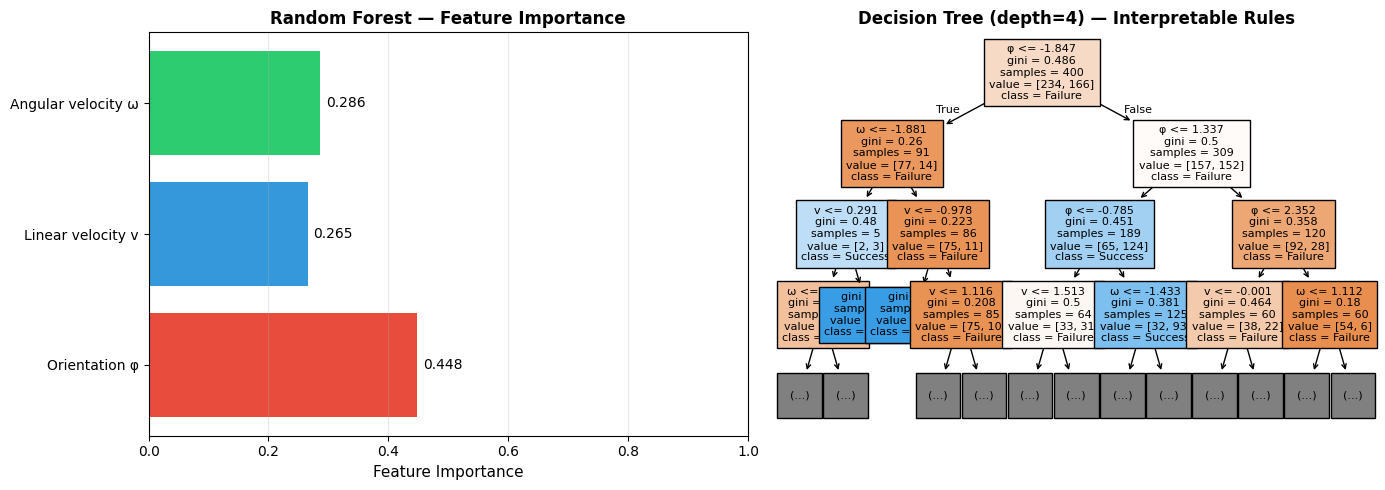

In [9]:
# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance bar chart
ax = axes[0]
importances = rf.feature_importances_
bars = ax.barh(features, importances, color=['#e74c3c', '#3498db', '#2ecc71'])
ax.set_xlabel('Feature Importance', fontsize=11)
ax.set_title('Random Forest — Feature Importance', fontsize=12, fontweight='bold')
ax.set_xlim(0, 1)
for bar, val in zip(bars, importances):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.grid(True, axis='x', alpha=0.3)

# Decision tree visualization
ax2 = axes[1]
plot_tree(dt, feature_names=['φ', 'v', 'ω'],
          class_names=['Failure', 'Success'],
          filled=True, max_depth=3, ax=ax2, fontsize=8)
ax2.set_title('Decision Tree (depth=4) — Interpretable Rules', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('xai_supervisor_demo.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Summary of Key Findings

This notebook reproduced the main results from the MSc thesis using synthetic data.

In [11]:
print('=' * 60)
print('  SUMMARY OF KEY FINDINGS')
print('=' * 60)
print()
print('1. INPUT SENSITIVITY (Exp1):')
print('   - Orientation φ is the dominant risk factor')
print('   - Failures concentrate near φ = ±π')
print('   - Angular velocity ω has secondary influence')
print()
print('2. GOAL DIFFICULTY (Exp2):')
print('   - Goal reachability is strongly goal-dependent')
print('   - DNN_LNA_closs2: 99.3% strict success (best)')
print('   - DNN_LNA_closs1: 25.3% strict success (worst)')
print('   - Gap of 74 percentage points between models')
print()
print('3. XAI SUPERVISOR:')
print(f'   - Random Forest: {rf_acc:.1%} accuracy')
print(f'   - Decision Tree: {dt_acc:.1%} accuracy (interpretable rules)')
print(f'   - Orientation φ most important feature: {rf.feature_importances_[0]:.3f}')
print()
print('4. PRACTICAL IMPLICATIONS:')
print('   - Dynamic command filtering for high-risk φ regions')
print('   - Hybrid fallback to classical planner for hard goals')
print('   - Predictive failure monitoring via soft success criteria')
print('=' * 60)
print()
print('Note: This notebook uses synthetic data to reproduce key patterns.')
print('Full results with real REXASI-PRO data are in results/figures_exp1/')
print('and results/figures_exp2/ — see the repository for details.')

  SUMMARY OF KEY FINDINGS

1. INPUT SENSITIVITY (Exp1):
   - Orientation φ is the dominant risk factor
   - Failures concentrate near φ = ±π
   - Angular velocity ω has secondary influence

2. GOAL DIFFICULTY (Exp2):
   - Goal reachability is strongly goal-dependent
   - DNN_LNA_closs2: 99.3% strict success (best)
   - DNN_LNA_closs1: 25.3% strict success (worst)
   - Gap of 74 percentage points between models

3. XAI SUPERVISOR:
   - Random Forest: 72.0% accuracy
   - Decision Tree: 69.0% accuracy (interpretable rules)
   - Orientation φ most important feature: 0.448

4. PRACTICAL IMPLICATIONS:
   - Dynamic command filtering for high-risk φ regions
   - Hybrid fallback to classical planner for hard goals
   - Predictive failure monitoring via soft success criteria

Note: This notebook uses synthetic data to reproduce key patterns.
Full results with real REXASI-PRO data are in results/figures_exp1/
and results/figures_exp2/ — see the repository for details.


---

## References

- Bathaei Pourmand, P. (2026). *Analysis of Neural Trajectory Prediction for Collision Avoidance in Smart Wheelchairs*. MSc Thesis, University of Genoa.
- REXASI-PRO Project: EU Horizon Europe, Grant Agreement No. 101070028-2
- GitHub: [github.com/pouyapd/SafeTraj-Experiments](https://github.com/pouyapd/SafeTraj-Experiments)